# Post-Pandemic Gender Labor Force Trends
Principle Investigators: Abigail Garvey, Anna Wang, Rachelle Lang - Group 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import datetime as dt

In [2]:
first_date = pd.to_datetime("2015-03-01")
COVID = pd.to_datetime("2020-03-01")
WINDOW = dt.timedelta(365*5) # looking 5 years before and after COVID (since that's what gives the biggest difference)

In [3]:
bls = pd.read_csv('../Data/lfpr.csv', parse_dates=['date'])
bls = bls.set_index('date')
bls = bls.loc[bls.index >= '2015-01-30']
bls.head()

,men,women
date,,
2015-02-01,69.2,56.6
2015-03-01,69.1,56.6
2015-04-01,69.3,56.7
2015-05-01,69.4,56.9
2015-06-01,69.0,56.8


Regress labor force participation rate on gender and pre/post COVID

In [4]:
# set up the dataset to handle the regression
bls_reg = bls.stack()
bls_reg = bls_reg.reset_index()
bls_reg.columns = ['date', 'female', 'lfpr']
bls_reg['female'] = bls_reg['female'].str.replace('women', '1').str.replace('men', '0')
bls_reg['female'] = bls_reg['female'].astype(int)
bls_reg = bls_reg.set_index('date')
bls_reg['pre'] = ((bls_reg.index < COVID) & (bls_reg.index >= COVID - WINDOW)).astype(int) # in the 5 years before COVID struck
bls_reg['post'] = ((bls_reg.index > COVID) & (bls_reg.index <= COVID + WINDOW)).astype(int) # in the 5 years after COVID
bls_reg = bls_reg[(bls_reg['pre'] == 1) | (bls_reg['post'] == 1)]
bls_reg.head()

,female,lfpr,pre,post
date,,,,
2015-04-01,0,69.3,1,0
2015-04-01,1,56.7,1,0
2015-05-01,0,69.4,1,0
2015-05-01,1,56.9,1,0
2015-06-01,0,69.0,1,0


In [5]:
# regress
DiD_reg = smf.ols('lfpr ~ female*post', bls_reg).fit()
DiD_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lfpr   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.288e+04
Date:                Fri, 12 Dec 2025   Prob (F-statistic):          1.19e-257
Time:                        21:14:28   Log-Likelihood:                -145.78
No. Observations:                 236   AIC:                             299.6
Df Residuals:                     232   BIC:                             313.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      69.0983      0.059   1172.587      0.000      68.982      69.214
female        -12.0407      0.083   -144.482      0.000     -12.205     -11.876
post           -1.2881      0.083    -15.457      0.000      -1.452      -1.124
female:post     0.9881      0.118      8.384      0.000       0.756       1.220
==============================================================================
Omnibus:                       44.076   Durbin-Watson:                   1.087
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              104.774
Skew:                          -0.860   Prob(JB):                     1.77e-23
Kurtosis:                       5.775   Cond. No.                         6.85
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

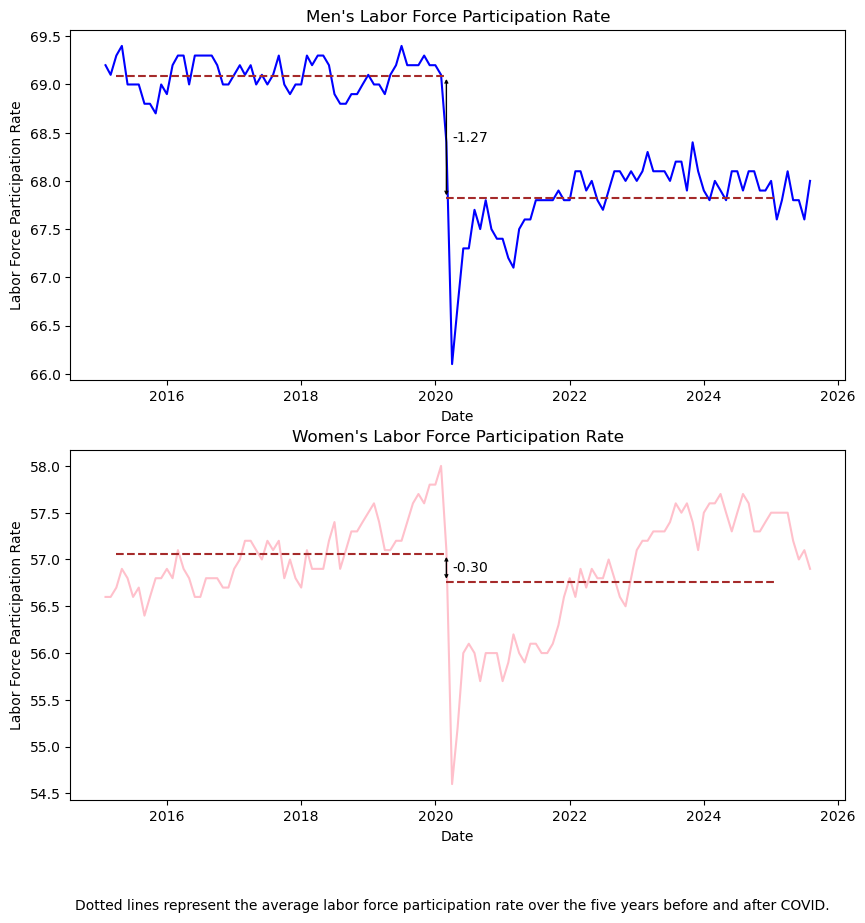

In [6]:
from dateutil.relativedelta import relativedelta

fig, ax = plt.subplots(2, figsize=(10, 10))

horizontal_color = 'brown'

men_before = bls.loc[COVID-WINDOW:COVID]['men'].mean()
women_before = bls.loc[COVID-WINDOW:COVID]['women'].mean()
men_after = bls.loc[COVID: COVID+WINDOW]['men'].mean()
women_after = bls.loc[COVID: COVID+WINDOW]['women'].mean()


ax[0].plot(bls.index, bls['men'], label='BLS Male', color='blue')
ax[1].plot(bls.index, bls['women'], label='BLS Female', color='pink')
ax[0].plot(bls.loc[COVID-WINDOW:COVID].index, [men_before]*len(bls.loc[COVID-WINDOW:COVID].index), linestyle='--', color=horizontal_color)
ax[0].plot(bls.loc[COVID:COVID+WINDOW].index, [men_after]*len(bls.loc[COVID:COVID+WINDOW].index), linestyle='--', color=horizontal_color)
ax[1].plot(bls.loc[COVID-WINDOW:COVID].index, [women_before]*len(bls.loc[COVID-WINDOW:COVID].index), linestyle='--', color=horizontal_color)
ax[1].plot(bls.loc[COVID:COVID+WINDOW].index, [women_after]*len(bls.loc[COVID:COVID+WINDOW].index), linestyle='--', color=horizontal_color)

# thanks chatgpt
ax[0].annotate(
    '', xy=(COVID, men_after), xytext=(COVID, men_before),
    arrowprops=dict(arrowstyle="<->", lw=1,  mutation_scale=5)
)
ax[0].text(COVID+relativedelta(months=1), (men_before+men_after)/2, f'{men_after-men_before: .2f}', va='center', ha='left')
ax[1].annotate(
    '', xy=(COVID, women_after), xytext=(COVID, women_before),
    arrowprops=dict(arrowstyle="<->", lw=1,  mutation_scale=5)
)
ax[1].text(COVID+relativedelta(months=1), (women_before+women_after)/2, f'{women_after-women_before: .2f}', va='center', ha='left')

ax[0].set_title("Men's Labor Force Participation Rate")
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Labor Force Participation Rate')
ax[1].set_title("Women's Labor Force Participation Rate")
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Labor Force Participation Rate')

fig.text(0.13, 0, 'Dotted lines represent the average labor force participation rate over the five years before and after COVID.')

plt.show()

In [7]:
fig.savefig('diffindifflike.svg',format='svg')

Now let's control for age group

In [8]:
# preparing age data to be visualized

bls_age = pd.read_csv('../Data/lfpr_ages.csv', parse_dates=['date'])
bls_age = bls_age.set_index('date')
#bls = bls.resample('Q').mean()
bls_age = bls_age.loc[bls_age.index >= '2015-01-30']

# smooth
bls_age = bls_age.sort_index()
rolling =  bls_age.groupby(['age', 'female'])['value'].rolling(12).mean()
rolling.name = 'rolling'
bls_age = pd.merge(bls_age, rolling, on=['age', 'female', 'date'])

# normalize
min_col = bls_age.groupby(['female', 'age'])['rolling'].min()
min_col.name = 'min'
max_col = bls_age.groupby(['female', 'age'])['rolling'].max()
max_col.name = 'max'
bls_age = bls_age.reset_index()
bls_age = pd.merge(bls_age, min_col, on=['female', 'age'])
bls_age = pd.merge(bls_age, max_col, on=['female', 'age'])
bls_age['normalized'] = (bls_age['rolling'] - bls_age['min']) / (bls_age['max'] - bls_age['min'])
bls_age = bls_age.set_index('date').sort_index()

# split by gender
bls_agem = bls_age[bls_age['female'] == 0]
bls_agew = bls_age[bls_age['female'] == 1]

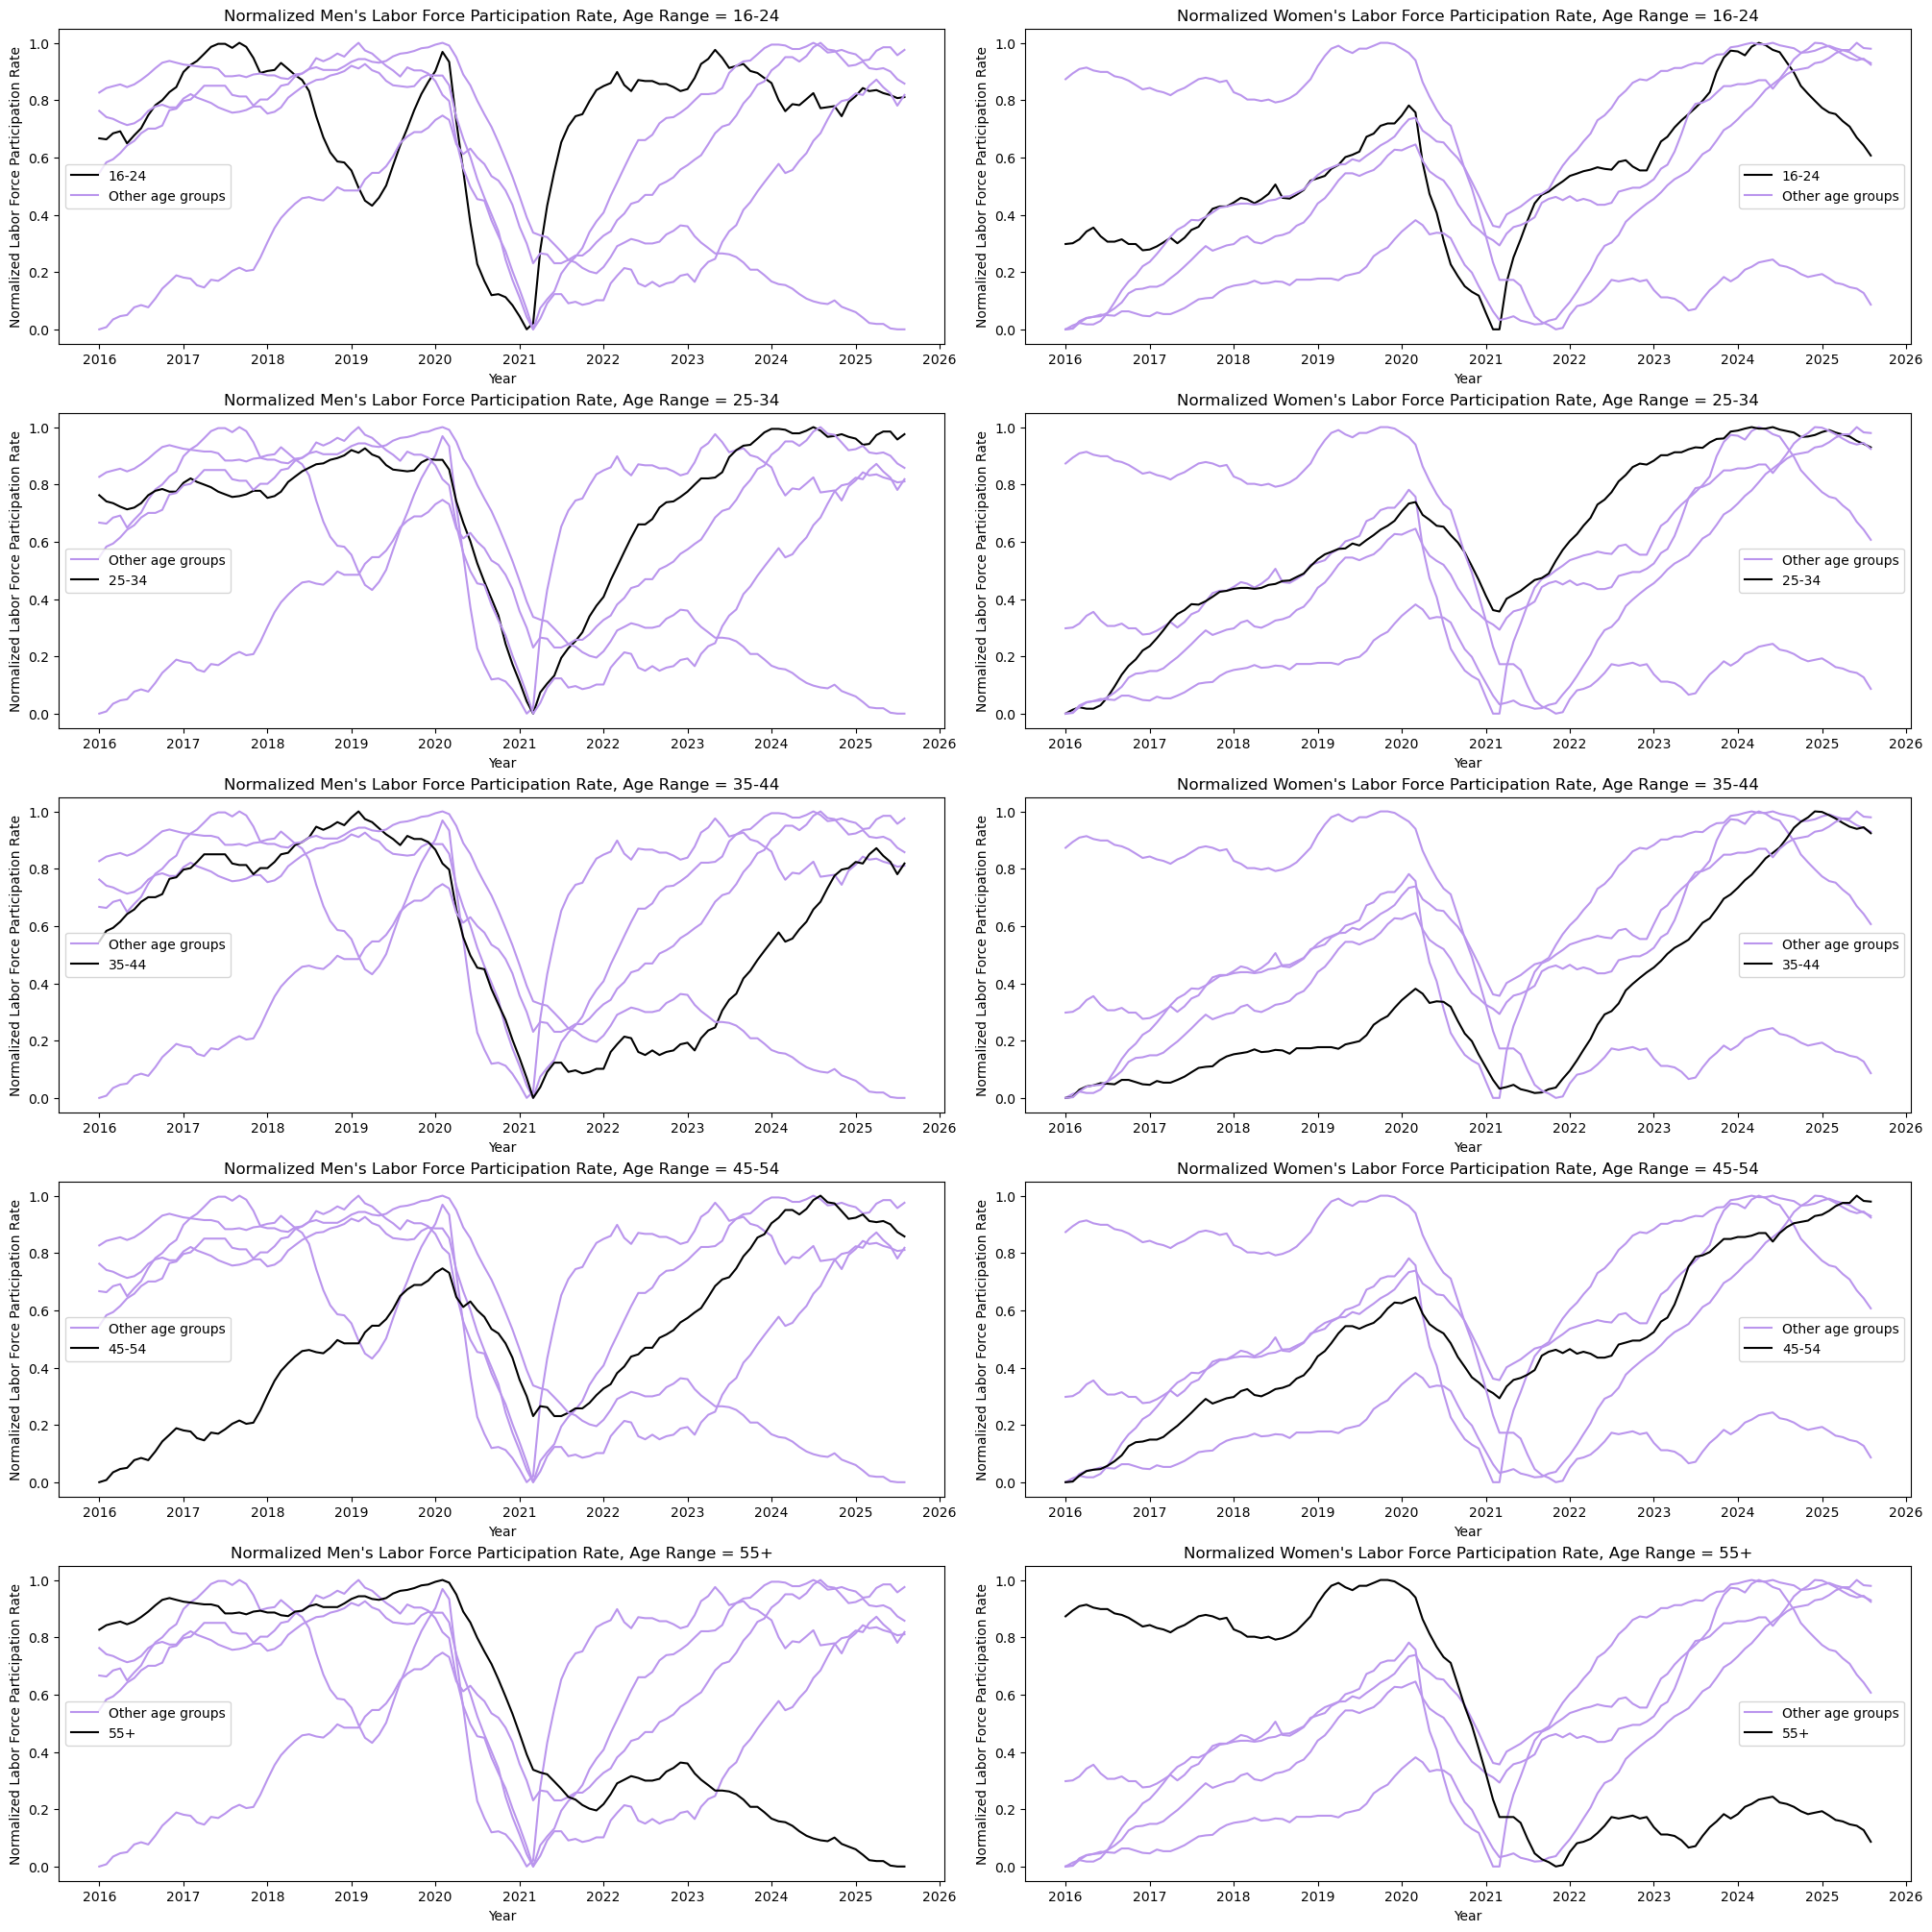

In [9]:
ages = sorted(bls_agem['age'].unique())

fig, ax = plt.subplots(len(ages), 2, constrained_layout=True, figsize=(20, 20))
background = '#BA95ED'
foreground = '#000000'

for a in range(len(ages)):
    other_label_used = False

    for i in range(0, len(ages)):
        to_plot = bls_agem[bls_agem['age'] == ages[i]]
        if i == a:
          c = foreground
          label = ages[a]
        else:
          c = background
          label = None
          if not other_label_used:
              label = "Other age groups"
              other_label_used = True
        ax[a,0].plot(to_plot.index, to_plot['normalized'], color=c, label = label)
        ax[a,0].legend()
    ax[a,0].set_title('Normalized Men\'s Labor Force Participation Rate, Age Range = ' + ages[a])
    ax[a,0].set_xlabel('Year')
    ax[a,0].set_ylabel("Normalized Labor Force Participation Rate")

    other_label_used = False
    for i in range(len(ages)):
        to_plot = bls_agew[bls_agew['age'] == ages[i]]
        if i == a:
          c = foreground
          label = ages[a]
        else:
          c = background
          label = None
          if not other_label_used:
              label = "Other age groups"
              other_label_used = True
        ax[a,1].plot(to_plot.index, to_plot['normalized'], color=c, label = label)
        ax[a,1].legend()
    ax[a,1].set_title('Normalized Women\'s Labor Force Participation Rate, Age Range = ' + ages[a])
    ax[a,1].set_xlabel('Year')
    ax[a,1].set_ylabel("Normalized Labor Force Participation Rate")


In [10]:
# Saving the table as an svg
fig.savefig('lfpr_vs_age.svg',format='svg')


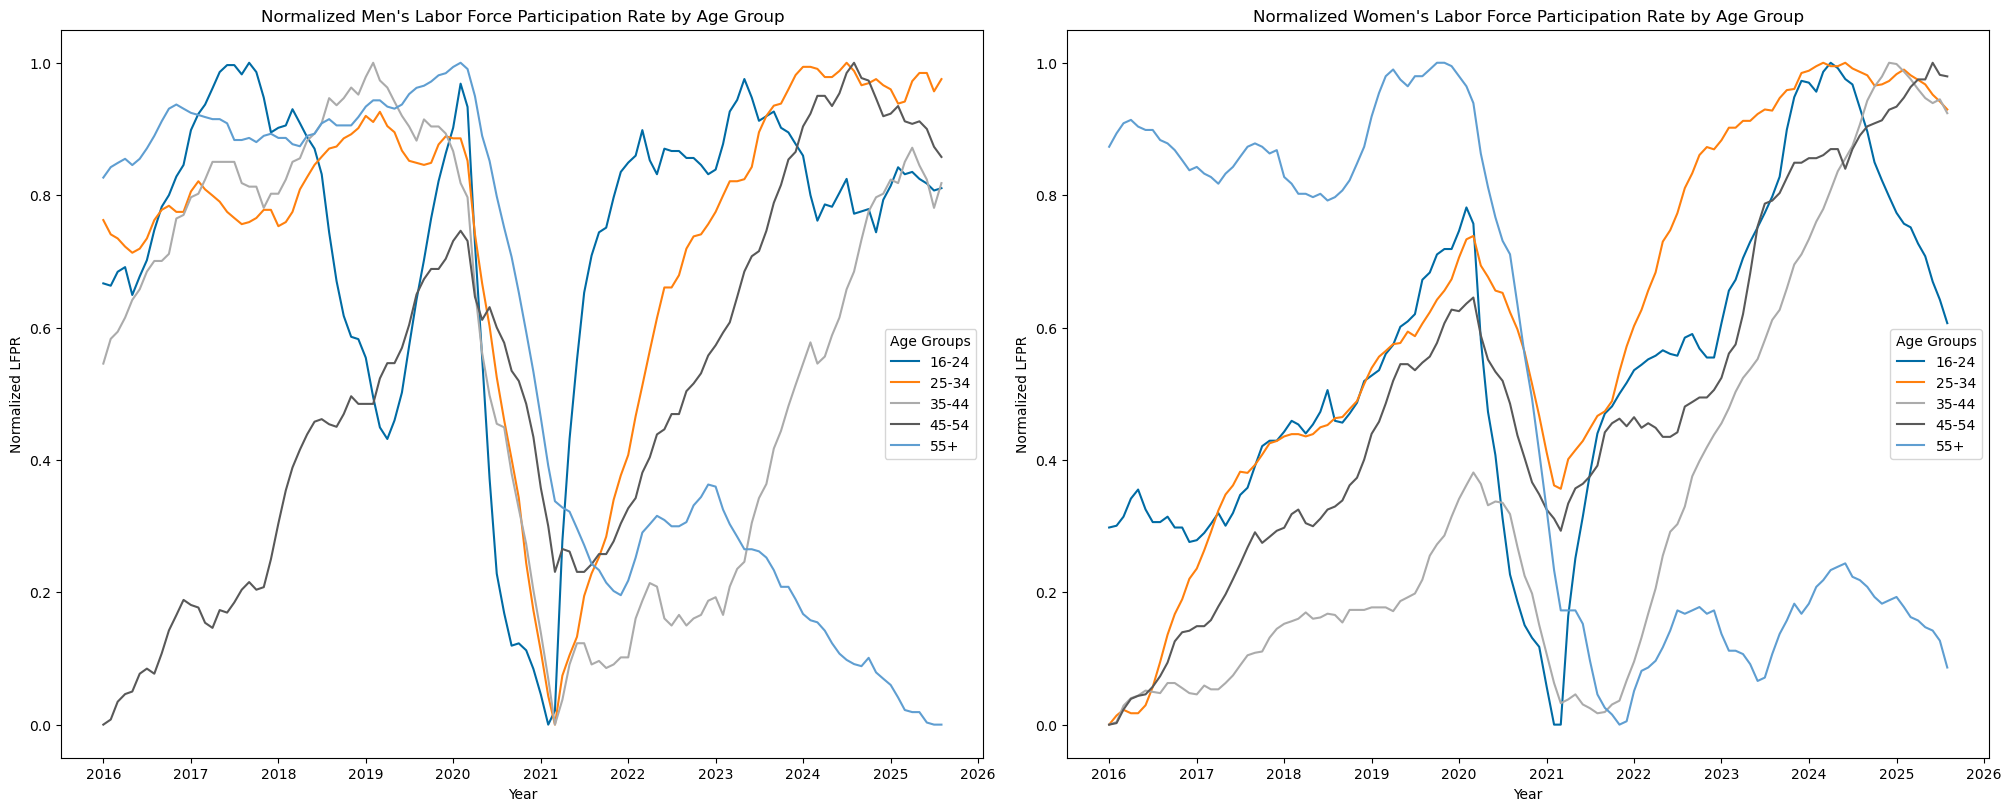

In [11]:
# showing the above plots of age group by gender as one plot for each gender with all the age groups
ages = sorted(bls_agem['age'].unique())
# using a colorblind friendly color palette
plt.style.use('tableau-colorblind10')
fig, ax = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

for i, age in enumerate(ages):
    to_plot = bls_agem[bls_agem['age'] == age]
    ax[0].plot(to_plot.index, to_plot["normalized"], label=age)

ax[0].set_title("Normalized Men's Labor Force Participation Rate by Age Group")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Normalized LFPR")
ax[0].legend(title="Age Groups")

for i, age in enumerate(ages):
    to_plot = bls_agew[bls_agew['age'] == age]
    ax[1].plot(to_plot.index, to_plot["normalized"], label=age)

ax[1].set_title("Normalized Women's Labor Force Participation Rate by Age Group")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Normalized LFPR")
ax[1].legend(title="Age Groups")

# Saving the table as an svg
fig.savefig('MvF_LFPR_Age.svg',format='svg')
plt.show()


In [12]:
# prepare age data for the regression
age_cols = sorted(['age' + a.replace('-', 'to').replace('+', 'andup') for a in bls_age['age'].unique()])
age_reg = bls_age[['female', 'age', 'rolling']]
age_reg[age_cols] = pd.get_dummies(age_reg['age'], dtype=int)
#epi_reg = epi_reg.drop('age_range', axis=1)
age_reg['pre'] = ((age_reg.index < COVID) & (age_reg.index >= COVID - WINDOW)).astype(int) # in the 5 years before COVID struck
age_reg['post'] = ((age_reg.index > COVID) & (age_reg.index <= COVID + WINDOW)).astype(int) # in the 5 years after COVID
age_reg = age_reg[(age_reg['pre'] == 1) | (age_reg['post'] == 1)]
age_reg.head()

C:\Users\famil\AppData\Local\Temp\ipykernel_18584\3116974055.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_reg[age_cols] = pd.get_dummies(age_reg['age'], dtype=int)
C:\Users\famil\AppData\Local\Temp\ipykernel_18584\3116974055.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_reg[age_cols] = pd.get_dummies(age_reg['age'], dtype=int)
C:\Users\famil\AppData\Local\Temp\ipykernel_18584\3116974055.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

,female,age,rolling,age16to24,age25to34,age35to44,age45to54,age55andup,pre,post
date,,,,,,,,,,
2015-04-01,1,25-34,NaN,0,1,0,0,0,1,0
2015-04-01,0,16-24,NaN,1,0,0,0,0,1,0
2015-04-01,1,55+,NaN,0,0,0,0,1,1,0
2015-04-01,0,55+,NaN,0,0,0,0,1,1,0
2015-04-01,1,16-24,NaN,1,0,0,0,0,1,0


In [13]:
# regression controlling for age
formula = 'rolling ~ ' + ' + '.join([a + '*post*female' for a in age_cols[1:]])
normal_res = smf.ols(formula, data=age_reg).fit()
normal_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                rolling   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.383e+04
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:14:47   Log-Likelihood:                -1101.7
No. Observations:                1090   AIC:                             2243.
Df Residuals:                    1070   BIC:                             2343.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 56.3683      0.095    594.012      0.000      56.182      56.555
age25to34                 32.5268      0.134    242.374      0.000      32.264      32.790
post                      -0.2065      0.129     -1.601      0.110      -0.460       0.047
age25to34:post            -0.2575      0.182     -1.412      0.158      -0.615       0.100
female                    -2.0402      0.134    -15.202      0.000      -2.303      -1.777
age25to34:female         -11.5665      0.190    -60.944      0.000     -11.939     -11.194
post:female                0.6323      0.182      3.466      0.001       0.274       0.990
age25to34:post:female      1.6371      0.258      6.346      0.000       1.131       2.143
age35to44                 34.3565      0.134    256.008      0.000      34.093      34.620
age35to44:post            -0.5490      0.182     -3.010      0.003      -0.907      -0.191
age35to44:female         -13.7622      0.190    -72.513      0.000     -14.135     -13.390
age35to44:post:female      1.4391      0.258      5.579      0.000       0.933       1.945
age45to54                 30.2625      0.134    225.502      0.000      29.999      30.526
age45to54:post             0.7713      0.182      4.228      0.000       0.413       1.129
age45to54:female         -10.0773      0.190    -53.098      0.000     -10.450      -9.705
age45to54:post:female     -0.1141      0.258     -0.442      0.658      -0.620       0.392
age55andup               -10.2448      0.134    -76.340      0.000     -10.508      -9.982
age55andup:post           -1.3725      0.182     -7.525      0.000      -1.730      -1.015
age55andup:female         -9.3130      0.190    -49.070      0.000      -9.685      -8.941
age55andup:post:female    -0.1353      0.258     -0.525      0.600      -0.641       0.371
==============================================================================
Omnibus:                       28.959   Durbin-Watson:                   1.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               63.028
Skew:                          -0.068   Prob(JB):                     2.06e-14
Kurtosis:                       4.170   Cond. No.                         41.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

ages 25-54 rebounded very much for women, but not so much for men.